In [1]:
import numpy as np 
from quspin.operators import hamiltonian, quantum_operator
from quspin.basis import spin_basis_1d
from quspin.tools.measurements import ent_entropy
import matplotlib.pyplot as plt

In [2]:
#define the model parameters
L=14
alpha=0.3
beta=0.5
lam1=1.0
k=3

## $k=3$ model

For the $k=3$ spin chain, we consider three sublattices labeled by

$$
a=0,1,2.
$$

For each fixed $a$, the sum over $j$ includes only sites satisfying

$$
j=a \pmod 3.
$$

Therefore, the three sublattices are

$$
\begin{aligned}
a=0 &: \quad j=0,3,6,9,\ldots,\\
a=1 &: \quad j=1,4,7,10,\ldots,\\
a=2 &: \quad j=2,5,8,11,\ldots.
\end{aligned}
$$

The $k=3$ Hamiltonian is

$$
H^{(3)}_s
=
\sum_{a=0}^{2}
\sum_{\substack{j=0\\ j=a\;(\mathrm{mod}\;3)}}^{L-1}
\alpha_{j,a}
\left[
e^{-\beta_a(X_j+X_{j+3})}
-
Z_jX_{j+1}X_{j+2}Z_{j+3}
\right].
$$

The coupling is defined by

$$
\boxed{
\alpha_{j,a}
=
|\alpha|
+
(-1)^{\frac{j-a}{3}},
\qquad
j=a\pmod 3.
}
$$

Thus, within each sublattice, the coupling alternates between

$$
\alpha_+ = |\alpha|+1,
\qquad
\alpha_- = |\alpha|-1,
$$

with $|\alpha|<1$.

For example, for the $a=0$ sublattice,

$$
\begin{aligned}
\alpha_{0,0} &= |\alpha|+1,\\
\alpha_{3,0} &= |\alpha|-1,\\
\alpha_{6,0} &= |\alpha|+1,\\
\alpha_{9,0} &= |\alpha|-1,\ldots
\end{aligned}
$$

Similarly, for $a=1$,

$$
\begin{aligned}
\alpha_{1,1} &= |\alpha|+1,\\
\alpha_{4,1} &= |\alpha|-1,\\
\alpha_{7,1} &= |\alpha|+1,\\
\alpha_{10,1} &= |\alpha|-1,\ldots
\end{aligned}
$$

and for $a=2$,

$$
\begin{aligned}
\alpha_{2,2} &= |\alpha|+1,\\
\alpha_{5,2} &= |\alpha|-1,\\
\alpha_{8,2} &= |\alpha|+1,\\
\alpha_{11,2} &= |\alpha|-1,\ldots
\end{aligned}
$$

Thus, each of the three sublattices has the same alternating pattern,

$$
\alpha_+,\alpha_-,\alpha_+,\alpha_-,\ldots
$$

but the three patterns are shifted relative to one another by one lattice site.

### Expansion of the exponential

Since $X_j$ and $X_{j+3}$ commute,

$$
e^{-\beta_a(X_j+X_{j+3})}
=
e^{-\beta_a X_j}
e^{-\beta_a X_{j+3}}.
$$

Using

$$
e^{-\beta_a X}
=
\cosh\beta_a-\sinh\beta_a X,
$$

we obtain

$$
\begin{aligned}
e^{-\beta_a(X_j+X_{j+3})}
&=
\left(
\cosh\beta_a-\sinh\beta_a X_j
\right)
\left(
\cosh\beta_a-\sinh\beta_a X_{j+3}
\right)
\\
&=
\cosh^2\beta_a
-\sinh\beta_a\cosh\beta_a\,X_j
-\sinh\beta_a\cosh\beta_a\,X_{j+3}
\\
&\quad
+\sinh^2\beta_a\,X_jX_{j+3}.
\end{aligned}
$$

Therefore, the expanded Hamiltonian is

$$
\begin{aligned}
H^{(3)}_s
=
\sum_{a=0}^{2}
\sum_{\substack{j=0\\j=a\;(\mathrm{mod}\;3)}}^{L-1}
\alpha_{j,a}
\Big[
&\cosh^2\beta_a
-\sinh\beta_a\cosh\beta_a\,X_j
\\
&-\sinh\beta_a\cosh\beta_a\,X_{j+3}
+\sinh^2\beta_a\,X_jX_{j+3}
\\
&-Z_jX_{j+1}X_{j+2}Z_{j+3}
\Big].
\end{aligned}
$$

### Sublattice construction in Python

The three sublattices can be constructed as

```python
SL0 = [j for j in range(L) if j % 3 == 0]  # a = 0
SL1 = [j for j in range(L) if j % 3 == 1]  # a = 1
SL2 = [j for j in range(L) if j % 3 == 2]  # a = 2

In [3]:
# ----- Basis -----
basis_even = spin_basis_1d(L, pauli=True, zblock=1)  # Pauli convention
basis_odd = spin_basis_1d(L, pauli=True, zblock=-1)  # Pauli convention

bases=[basis_even,basis_odd]
full_basis=spin_basis_1d(L, pauli=True)

In [4]:
def alpha_aj(j, alpha, a):
    return alpha + (-1)**((j - a)//3)

In [5]:
def add_block(SL, beta, L, alpha, a, defect_site=None):
    c = np.cosh(beta)
    s = np.sinh(beta)

    a0    = []
    axL   = []
    axR   = []
    axx   = []
    azxxz = []

    for j in SL:

        jp1 = (j + 1) % L
        jp2 = (j + 2) % L
        jp3 = (j + 3) % L

        coeff = lam1 * alpha_aj(j, alpha, a)

        # Normal cluster term
        cluster_coeff = -coeff

        # Flip only one cluster term if a defect is present
        if defect_site is not None and j == defect_site:
            cluster_coeff = +coeff

        # exp[-beta (X_j + X_{j+3})]
        a0.append([coeff * c**2, j])

        axL.append([-coeff * s * c, j])

        axR.append([-coeff * s * c, jp3])

        axx.append([coeff * s**2, j, jp3])

        # -/+ Z_j X_{j+1} X_{j+2} Z_{j+3}
        azxxz.append([
            cluster_coeff,
            j,
            jp1,
            jp2,
            jp3
        ])

    return [
        ['I',    a0],
        ['x',    axL],
        ['x',    axR],
        ['xx',   axx],
        ['zxxz', azxxz],
    ]

In [ ]:
# Three sublattices for k = 3
SL0 = [j for j in range(L) if j % 3 == 0]  # a = 0
SL1 = [j for j in range(L) if j % 3 == 1]  # a = 1
SL2 = [j for j in range(L) if j % 3 == 2]  # a = 2


# Choose subsystem (half-chain here)
subsystem_size = L // 2
subsys_A = list(range(subsystem_size))

full_energies = []
full_states   = []
full_entropies = []

for basis in bases:

    static_spin = []

    # a = 0 sector: j = 0, 3, 6, 9, ...
    # No defect
    static_spin += add_block(
        SL0,
        beta,
        L,
        alpha,
        a=0,
        defect_site=None
    )

    # a = 1 sector: j = 1, 4, 7, 10, ...
    # One defect at j = 7 or for No defect use None
    static_spin += add_block(
        SL1,
        beta,
        L,
        alpha,
        a=1,
        defect_site=None
    )

    # a = 2 sector: j = 2, 5, 8, 11, ...
    # No defect
    static_spin += add_block(
        SL2,
        beta,
        L,
        alpha,
        a=2,
        defect_site=None
    )

    dynamic_spin = []

    # Build Hamiltonian
    H = hamiltonian(
        static_spin,
        dynamic_spin,
        basis=basis,
        check_symm=False,
        dtype=np.complex128
    )

    # Diagonalize
    energies, states = H.eigh()

    # Compute entanglement entropies
    entropies = np.zeros(states.shape[1])

    for i, state in enumerate(states.T):

        entropy_dict = ent_entropy(
            state.T,
            basis=basis,
            chain_subsys=subsys_A,
            density=False
        )

        entropies[i] = entropy_dict['Sent_A']

    # Project to full basis
    full_s = basis.project_from(states, full_basis)

    full_states.append(full_s)
    full_energies.append(energies)
    full_entropies.append(entropies)

Hermiticity check passed!
Hermiticity check passed!


In [32]:
from scipy.sparse import hstack

full_spec = np.concatenate((full_energies[0], full_energies[1]))
full_vecs = hstack([full_states[0], full_states[1]])
full_entropies_all = np.concatenate((full_entropies[0], full_entropies[1]))

In [33]:
#sort everything
sorted_indices=np.argsort(full_spec)
sorted_entropies=full_entropies_all[sorted_indices]
sorted_energies=full_spec[sorted_indices]

In [34]:
# Generate data
# Save everything after the loop

np.savez(
    "quspin_simulation_data_k3_chain_None_defects.npz",
    sorted_indices=np.argsort(full_spec),
    energies=np.array(full_energies, dtype=object),
    entropies=np.array(full_entropies, dtype=object),
    L=L,
    alpha=alpha,
    beta=beta,
    defect_site_SL0=None,
    defect_site_SL1=None,
    defect_site_SL2=None,
)

In [38]:
data = np.load(
    "quspin_simulation_data_k3_chain_None_defects.npz",
    allow_pickle=True
)

sorted_indices = data["sorted_indices"]
full_energies = data["energies"].tolist()
full_entropies = data["entropies"].tolist()
L = int(data["L"])
alpha = float(data["alpha"])
beta = float(data["beta"])

In [30]:
# Generate data
# Save everything after the loop

np.savez(
    "quspin_simulation_data_k3_chain_1_defects.npz",
    sorted_indices=np.argsort(full_spec),
    energies=np.array(full_energies, dtype=object),
    entropies=np.array(full_entropies, dtype=object),
    L=L,
    alpha=alpha,
    beta=beta,
    defect_site_SL0=None,
    defect_site_SL1=7,
    defect_site_SL2=None,
)

In [ ]:
data = np.load(
    "quspin_simulation_data_k3_chain_1_defects.npz",
    allow_pickle=True
)

sorted_indices = data["sorted_indices"]
full_energies = data["energies"].tolist()
full_entropies = data["entropies"].tolist()
L = int(data["L"])
alpha = float(data["alpha"])
beta = float(data["beta"])

In [35]:
#Plotting entropy with the symmetry breaking perturbations. Set the style of the plot
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
})

In [36]:
tol=1e-12
scars_idx=np.where((sorted_entropies<3) & (np.abs(sorted_energies)<tol))[0]
scars_idx

array([887, 888])

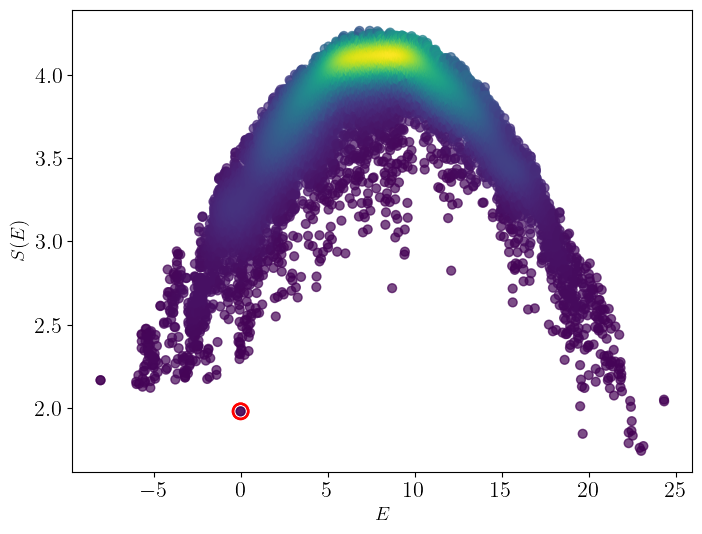

In [39]:
from scipy.stats import gaussian_kde
# Calculate point density for the entire plot area
xy = np.vstack([sorted_energies, sorted_entropies])
density = gaussian_kde(xy)(xy)

# Plotting
plt.figure(figsize=(8, 6), dpi=100)
plt.scatter(sorted_energies, sorted_entropies, c=density, s=40, cmap='viridis', alpha=0.7)

# Scar states
plt.scatter(
    sorted_energies[scars_idx],
    sorted_entropies[scars_idx],
    facecolors='none',
    edgecolors='red',
    marker='o',
    s=120,
    linewidths=1.8,
    label='Scar states',
    zorder=3
)

# Labels and title with LaTeX formatting
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$S(E)$", fontsize=14)

plt.grid(False)
#plt.savefig("Entropy_k3_chain_1_defect_L14.pdf",bbox_inches="tight")
plt.show()